In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [14]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('rs-18-track-a')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/rs-18-track-a


In [15]:
# ==============================================
# Step 1-1. 캐글 입력 데이터 폴더 구조 확인
# ==============================================
import os

# 캐글 노트북에서는 데이터가 항상 /kaggle/input/ 아래에 읽기 전용으로 마운트됨
INPUT_ROOT = '/kaggle/input'

# input 폴더 바로 아래에 어떤 대회/데이터셋 폴더들이 있는지 확인
for dataset_name in os.listdir(INPUT_ROOT):
    dataset_path = os.path.join(INPUT_ROOT, dataset_name)
    print(f"[폴더] {dataset_name}")
    # 그 안에 어떤 파일/폴더가 있는지 한 단계 더 확인
    for item in os.listdir(dataset_path):
        print(f"   ├─ {item}")

[폴더] competitions
   ├─ rs-18-track-a


In [16]:
# ==============================================
# Step 1-2. rs-18-track-a 폴더 내부 구조 상세 확인
# ==============================================
import os

# 위에서 확인한 대회 데이터 경로
COMP_PATH = '/kaggle/input/competitions/rs-18-track-a'

# 폴더 안의 파일/폴더 목록을 재귀적으로 출력 (하위 폴더까지 한번 더 확인)
for root, dirs, files in os.walk(COMP_PATH):
    # 너무 깊은 하위 폴더(이미지 수백 장)는 개수만 세고 넘어가도록 처리
    depth = root.replace(COMP_PATH, '').count(os.sep)
    indent = '   ' * depth
    print(f"{indent}[폴더] {os.path.basename(root) if root != COMP_PATH else root}")
    
    # 파일이 너무 많으면(이미지 폴더) 개수만 출력
    if len(files) > 10:
        print(f"{indent}   └─ 파일 {len(files)}개 (예: {files[:3]})")
    else:
        for f in files:
            print(f"{indent}   ├─ {f}")

[폴더] /kaggle/input/competitions/rs-18-track-a
   ├─ sample_submission.csv
   ├─ train_labels.csv
   [폴더] test
      └─ 파일 468개 (예: ['test_00121.jpg', 'test_00432.jpg', 'test_00180.jpg'])
   [폴더] train
      └─ 파일 1366개 (예: ['train_00232.jpg', 'train_00259.jpg', 'train_01167.jpg'])


In [17]:
# ==============================================
# Step 2. 기본 경로 설정 및 CSV 파일 로드
# ==============================================
import os
import pandas as pd

# 대회 데이터가 위치한 루트 경로 (앞서 확인한 구조 기준)
COMP_PATH = '/kaggle/input/competitions/rs-18-track-a'

# train 라벨 CSV 경로와 sample_submission CSV 경로
train_csv_path = os.path.join(COMP_PATH, 'train_labels.csv')
sub_csv_path = os.path.join(COMP_PATH, 'sample_submission.csv')

# train 이미지 폴더, test 이미지 폴더 경로
train_img_dir = os.path.join(COMP_PATH, 'train')
test_img_dir = os.path.join(COMP_PATH, 'test')

# CSV 파일을 Pandas DataFrame으로 읽기
train_df = pd.read_csv(train_csv_path)
sub_df = pd.read_csv(sub_csv_path)

# 데이터가 잘 로드되었는지 확인
print("--- Train Labels (상위 5개) ---")
print(train_df.head())
print(f"\ntrain_df 전체 행 개수: {len(train_df)}")

print("\n--- Sample Submission (상위 5개) ---")
print(sub_df.head())
print(f"\nsub_df 전체 행 개수: {len(sub_df)}")

--- Train Labels (상위 5개) ---
            id  label
0  train_00000      0
1  train_00001      1
2  train_00002      0
3  train_00003      1
4  train_00004      1

train_df 전체 행 개수: 1366

--- Sample Submission (상위 5개) ---
           id  dusty_prob
0  test_00000         0.5
1  test_00001         0.5
2  test_00002         0.5
3  test_00003         0.5
4  test_00004         0.5

sub_df 전체 행 개수: 468


In [10]:
# ==============================================
# Step 3-2 (수정). 필요 라이브러리 임포트 - transformers 제외
# ==============================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [11]:
# ==============================================
# Step 4-1. 경로 변수 재정리
# ==============================================
COMP_PATH = '/kaggle/input/competitions/rs-18-track-a'   # 대회 데이터 루트 경로
train_img_dir = os.path.join(COMP_PATH, 'train')         # train 이미지 폴더
test_img_dir = os.path.join(COMP_PATH, 'test')           # test 이미지 폴더

train_csv_path = os.path.join(COMP_PATH, 'train_labels.csv')       # train 라벨 csv
sub_csv_path = os.path.join(COMP_PATH, 'sample_submission.csv')    # 제출 양식 csv

train_df = pd.read_csv(train_csv_path)   # train 라벨 데이터프레임
sub_df = pd.read_csv(sub_csv_path)       # 제출 양식 데이터프레임

print(f"train_df 행 개수: {len(train_df)}")
print(f"train 이미지 폴더 파일 개수: {len(os.listdir(train_img_dir))}")

train_df 행 개수: 1366
train 이미지 폴더 파일 개수: 1366


In [12]:
# ==============================================
# Step 4-2. 커스텀 Dataset 클래스 정의
# ==============================================
class DLthonDataset(Dataset):
    """
    이미지 id + label 정보가 담긴 DataFrame을 받아서
    실제 이미지 파일을 열고, 전처리(transform)를 적용해 반환하는 Dataset 클래스
    """
    def __init__(self, data_dir, df, transform=None):
        self.data_dir = data_dir   # 이미지가 들어있는 폴더 경로
        self.df = df               # id, label 컬럼을 가진 DataFrame
        self.transform = transform # 이미지에 적용할 전처리 파이프라인

    def __len__(self):
        return len(self.df)   # 데이터셋 전체 샘플 개수

    def __getitem__(self, idx):
        img_id = self.df.iloc[idx]['id']                        # idx번째 행의 id 값
        img_path = os.path.join(self.data_dir, f"{img_id}.jpg")  # 이미지 전체 경로
        image = Image.open(img_path).convert("RGB")              # 이미지 열고 RGB로 변환

        # label 컬럼이 있으면 라벨 반환, 없으면(test셋) -1
        label = self.df.iloc[idx]['label'] if 'label' in self.df.columns else -1

        if self.transform:
            image = self.transform(image)   # 전처리 적용 (리사이즈, 텐서 변환 등)

        return image, label, idx   # 이미지, 라벨, 원본 인덱스 반환

In [13]:
# ==============================================
# Step 5. timm으로 DINOv2 임베딩 모델 불러오기 (transformers 우회)
# ==============================================
# timm 라이브러리에 등록된 DINOv2 backbone을 직접 로드
# 'vit_small_patch14_dinov2.lvd142m' : DINOv2로 사전학습된 ViT-Small 모델
# num_classes=0 옵션을 주면 분류head 없이 특징 벡터(임베딩)만 추출하는 모드가 됨
embed_model = timm.create_model(
    'vit_small_patch14_dinov2.lvd142m',
    pretrained=True,
    num_classes=0
).to(device)

embed_model.eval()   # 추론 모드로 설정 (dropout/batchnorm 등 학습용 동작 비활성화)

# timm 모델에 맞는 전처리(transform) 설정값을 모델 config에서 자동으로 가져옴
data_config = timm.data.resolve_model_data_config(embed_model)
dino_transform = timm.data.create_transform(**data_config, is_training=False)

print("DINOv2 (timm) 임베딩 모델 준비 완료")
print(f"전처리 설정: {data_config}")

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

DINOv2 (timm) 임베딩 모델 준비 완료
전처리 설정: {'input_size': (3, 518, 518), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}


In [14]:
# ==============================================
# Step 6-1. 임베딩 추출용 DataLoader 준비
# ==============================================
# DINOv2 전용 transform(dino_transform)을 적용한 Dataset 생성
train_dataset_dino = DLthonDataset(train_img_dir, train_df, transform=dino_transform)

# 배치 단위로 이미지를 묶어서 GPU에 넘기기 위한 DataLoader
# shuffle=False로 해야 나중에 idx와 원본 순서가 정확히 매칭됨
train_loader_dino = DataLoader(
    train_dataset_dino,
    batch_size=32,      # 한 번에 처리할 이미지 개수 (메모리 부족하면 16으로 줄이기)
    shuffle=False,
    num_workers=2        # 이미지 로딩을 병렬로 처리할 프로세스 개수
)

print(f"총 배치 개수: {len(train_loader_dino)}")

총 배치 개수: 43


In [15]:
# ==============================================
# Step 6-2. 배치 단위로 임베딩 추출
# ==============================================
embeddings_list = []   # 각 배치의 임베딩을 저장할 리스트
labels_list = []       # 각 배치의 라벨을 저장할 리스트
idx_list = []          # 원본 DataFrame에서의 순서(idx)를 저장할 리스트

with torch.no_grad():   # 추론 시에는 gradient 계산이 필요없으므로 메모리/속도 최적화
    for batch_idx, (images, labels, idxs) in enumerate(train_loader_dino):
        images = images.to(device)              # 이미지 배치를 GPU로 이동

        features = embed_model(images)          # DINOv2로 특징 벡터(임베딩) 추출
        features = features.cpu().numpy()       # 결과를 CPU로 옮기고 numpy 배열로 변환

        embeddings_list.append(features)        # 리스트에 누적
        labels_list.extend(labels.numpy())      # 라벨도 누적
        idx_list.extend(idxs.numpy())           # 원본 인덱스도 누적

        # 진행 상황 출력 (10배치마다)
        if batch_idx % 10 == 0:
            print(f"진행 중... {batch_idx}/{len(train_loader_dino)} 배치 완료")

# 리스트에 쌓인 배치별 임베딩을 하나의 큰 numpy 배열로 합치기
embeddings = np.vstack(embeddings_list)
labels_array = np.array(labels_list)
idx_array = np.array(idx_list)

print(f"\n최종 임베딩 shape: {embeddings.shape}")   # (샘플 수, 임베딩 차원)
print(f"라벨 배열 shape: {labels_array.shape}")

진행 중... 0/43 배치 완료
진행 중... 10/43 배치 완료
진행 중... 20/43 배치 완료
진행 중... 30/43 배치 완료
진행 중... 40/43 배치 완료

최종 임베딩 shape: (1366, 384)
라벨 배열 shape: (1366,)


Step 6-1 (DataLoader 준비)

1366장의 train 이미지를 한 장씩 처리하면 느리니까, 32장씩 묶어서(배치) GPU에 넘기도록 설정
shuffle=False가 중요 — 순서를 뒤섞지 않아야 나중에 임베딩 결과를 원본 train_df의 몇 번째 행이었는지 정확히 되짚을 수 있음.
1366장 ÷ 32 = 약 43배치 → 로그에 찍힌 "총 배치 개수: 43"이 이걸 확인

Step 6-2 (임베딩 추출 루프)

with torch.no_grad(): 지금은 모델을 학습시키는 게 아니라 특징만 뽑아내는(추론) 작업이라, 역전파용 그래디언트 계산을 꺼서 메모리와 속도를 아낌.
각 배치를 DINOv2에 통과시키면, 이미지 한 장당 원래 픽셀 정보(3×518×518 = 80만 개 숫자)가 **384개의 숫자로 압축된 벡터(임베딩)**로 바뀜. 이 384차원 벡터는 "이 이미지가 어떤 이미지인지"를 압축한 지문 같은 것
43개 배치를 다 돌면서 나온 결과를 리스트에 쌓았다가, np.vstack으로 하나의 큰 표(행렬)로 합침.

결과 해석

임베딩 shape: (1366, 384) → 1366장의 이미지 각각이 384개 숫자로 표현된 표. 행이 이미지, 열이 특징(feature)
이제 이 384차원 벡터들끼리 비교하면:

비슷한 벡터를 가진 두 이미지 → 실제로도 비슷하게 생긴 이미지 (중복 의심 → dup_score)
다른 벡터들과 확 떨어진(고립된) 벡터를 가진 이미지 → 태양광 패널이 아닌 이상한 이미지일 가능성 (ood_score)

In [16]:
# ==============================================
# Step 7. OOD Score 계산 (주제 이탈 = 패널이 아닌 이미지 탐지)
# ==============================================
# "주제 이탈"이란: 태양광 패널이 아니거나(그래픽·설비·풍경 등),
# 패널이 중심이 아니라서 Clean/Dusty 판단이 불가능한 이미지를 의미함
#
# LOF(Local Outlier Factor): 각 이미지가 주변 이웃들(비슷한 임베딩을 가진 이미지들)과
# 비교했을 때 얼마나 "밀도가 낮은 외딴 곳"에 혼자 떨어져 있는지를 측정하는 알고리즘
# → 대부분의 이미지가 "태양광 패널" 도메인에 몰려있다면,
#    패널이 아닌 이미지는 이 밀집된 군집에서 멀리 떨어진 이상치로 나타날 것이라는 가정

# n_neighbors=20: 각 이미지 주변 20개의 가까운 이웃을 기준으로 밀도를 계산
# novelty=False: 학습에 쓴 데이터 자체의 이상치를 판단하는 모드 (지금 상황에 맞음)
lof = LocalOutlierFactor(n_neighbors=20, novelty=False)
lof.fit(embeddings)   # DINOv2로 뽑은 임베딩을 기준으로 밀도 계산

# lof.negative_outlier_factor_ : 값이 작을수록(더 음수일수록) 밀도가 낮은 이상치라는 뜻
nof = lof.negative_outlier_factor_

# 방향을 뒤집어서 "이상치일수록(=주제 이탈일수록) 점수가 높아지도록" 만들고,
# 0~1 사이로 Min-Max 정규화 (컴페티션 제출 형식에 맞추기 위함)
ood_scores = (nof.max() - nof) / (nof.max() - nof.min())

print(f"ood_score 범위: {ood_scores.min():.4f} ~ {ood_scores.max():.4f}")
print(f"ood_score 평균: {ood_scores.mean():.4f}")

# 점수가 가장 높은(주제 이탈 의심이 가장 큰) 상위 5개 이미지의 id 확인
top_ood_idx = np.argsort(ood_scores)[::-1][:5]   # 내림차순 정렬 후 상위 5개 인덱스
print("\n주제 이탈 의심 상위 5개:")
for i in top_ood_idx:
    print(f"  id: {train_df.iloc[i]['id']}, ood_score: {ood_scores[i]:.4f}")

ood_score 범위: 0.0000 ~ 1.0000
ood_score 평균: 0.1757

주제 이탈 의심 상위 5개:
  id: train_01352, ood_score: 1.0000
  id: train_00200, ood_score: 0.9500
  id: train_01213, ood_score: 0.8904
  id: train_00878, ood_score: 0.8167
  id: train_01152, ood_score: 0.8127


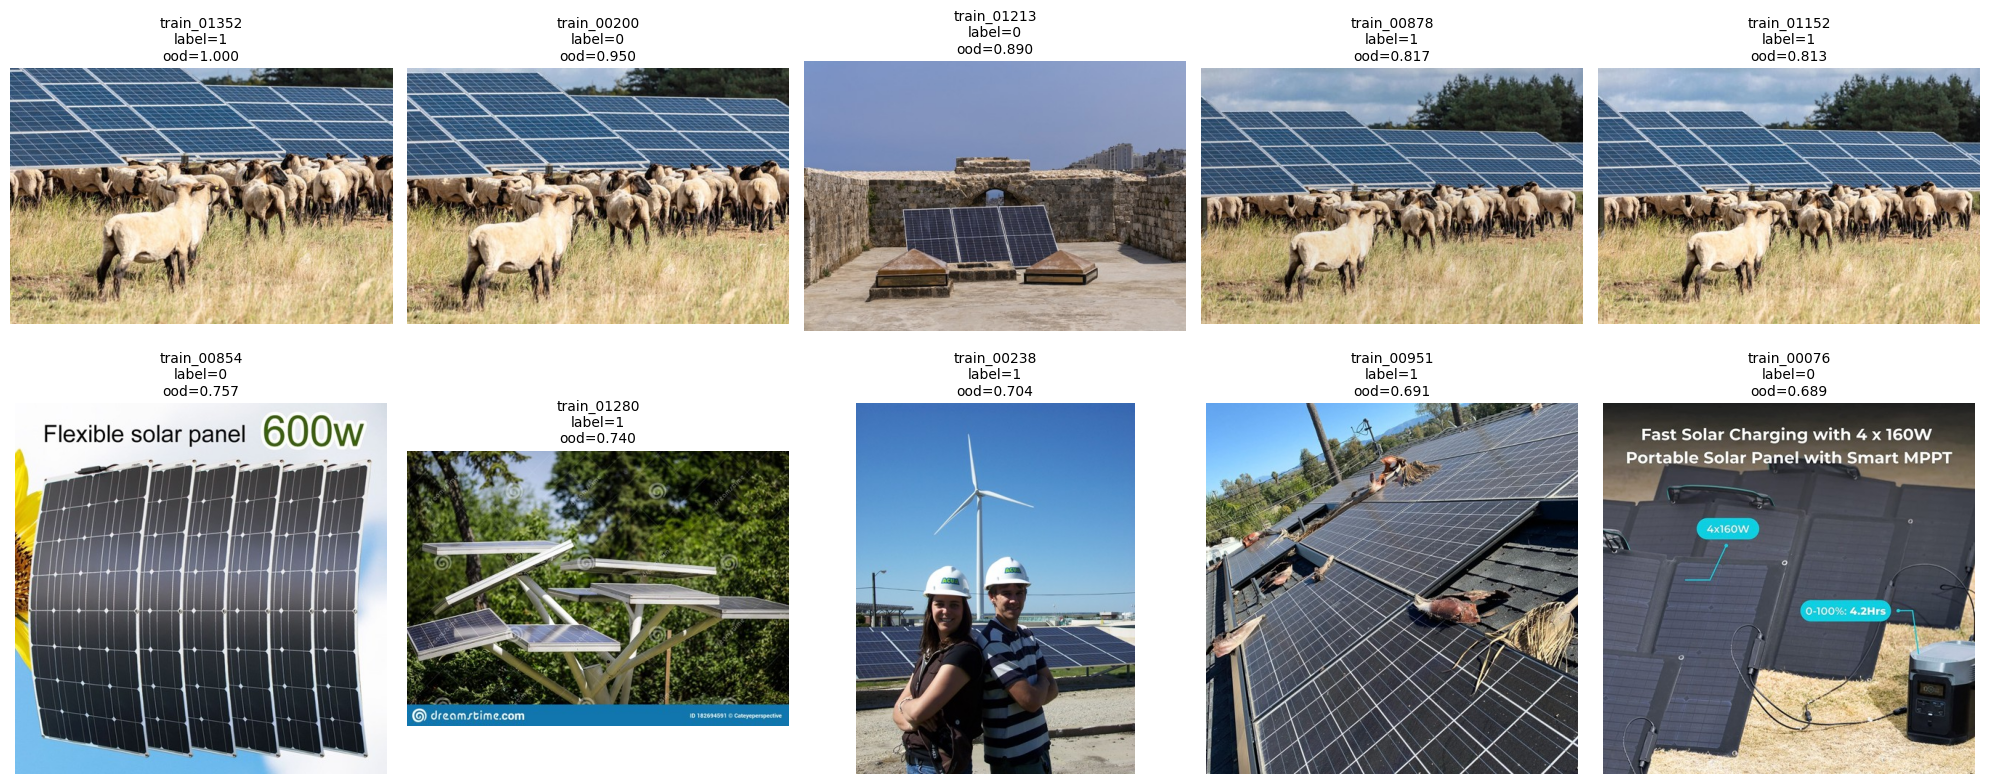

In [17]:
# ==============================================
# Step 7-보너스. OOD 의심 상위 이미지 눈으로 확인
# ==============================================
# ood_score가 높게 나온 이미지들이 정말로 "패널이 아닌 이미지"인지
# 직접 눈으로 확인해서 알고리즘이 잘 작동하는지 검증하는 단계

top_n = 10   # 상위 몇 개를 볼지 설정
top_ood_idx = np.argsort(ood_scores)[::-1][:top_n]   # ood_score 내림차순 상위 top_n개 인덱스

fig, axes = plt.subplots(2, 5, figsize=(20, 8))   # 2행 5열 격자로 이미지 배치
axes = axes.flatten()

for plot_idx, data_idx in enumerate(top_ood_idx):
    img_id = train_df.iloc[data_idx]['id']                          # 이미지 id
    img_label = train_df.iloc[data_idx]['label']                    # 원래 라벨
    img_path = os.path.join(train_img_dir, f"{img_id}.jpg")         # 이미지 경로
    img = Image.open(img_path)                                      # 이미지 열기

    axes[plot_idx].imshow(img)
    axes[plot_idx].set_title(f"{img_id}\nlabel={img_label}\nood={ood_scores[data_idx]:.3f}", fontsize=10)
    axes[plot_idx].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# ==============================================
# Step 8. Dup Score 계산 (근접 중복 이미지 탐지)
# ==============================================
# 모든 이미지 쌍 사이의 코사인 유사도 행렬 계산
# (1366, 1366) 크기: [i][j] = i번째 이미지와 j번째 이미지의 임베딩 유사도 (-1~1, 보통 0~1)
sim_matrix = cosine_similarity(embeddings)

# 자기 자신과의 유사도(항상 1.0)는 의미 없으므로 대각선을 0으로 지움
np.fill_diagonal(sim_matrix, 0)

# 각 이미지마다, 자기 자신을 제외하고 "가장 비슷한 다른 이미지"와의 유사도를 dup_score로 사용
# 값이 1에 가까울수록 어딘가에 거의 똑같이 생긴 이미지가 존재한다는 뜻
dup_scores = np.max(sim_matrix, axis=1)

print(f"dup_score 범위: {dup_scores.min():.4f} ~ {dup_scores.max():.4f}")
print(f"dup_score 평균: {dup_scores.mean():.4f}")

# 점수가 가장 높은(중복 의심이 가장 큰) 상위 5개 확인
top_dup_idx = np.argsort(dup_scores)[::-1][:5]
print("\n중복 의심 상위 5개:")
for i in top_dup_idx:
    partner_idx = np.argmax(sim_matrix[i])   # 이 이미지와 가장 비슷한 짝 이미지의 인덱스
    print(f"  id: {train_df.iloc[i]['id']} <-> 가장 비슷한 상대: {train_df.iloc[partner_idx]['id']}, dup_score: {dup_scores[i]:.4f}")

dup_score 범위: 0.3587 ~ 0.9997
dup_score 평균: 0.9154

중복 의심 상위 5개:
  id: train_00447 <-> 가장 비슷한 상대: train_00087, dup_score: 0.9997
  id: train_00087 <-> 가장 비슷한 상대: train_00447, dup_score: 0.9997
  id: train_01118 <-> 가장 비슷한 상대: train_00042, dup_score: 0.9996
  id: train_00042 <-> 가장 비슷한 상대: train_01118, dup_score: 0.9996
  id: train_01343 <-> 가장 비슷한 상대: train_00126, dup_score: 0.9995


OOD 결과 설명

결과 보니까 LOF가 진짜 일 제대로 함. 상위 10개 중에서:
확실한 주제 이탈 (off-topic) 케이스:

train_00854: 광고 그래픽(600W 태양광 패널 상품 이미지) — 실제 현장 사진이 아니라 마케팅 이미지임
train_01280: dreamstime 워터마크 박힌 스톡 이미지, 실제 패널이 아니라 예술적/합성 구조물처럼 보임
train_00076: "Fast Solar Charging" 텍스트 오버레이 있는 상품 광고 이미지
train_00238: 사람 두 명이 헬멧 쓰고 포즈 잡은 사진 — 패널은 배경에 작게 있고 사람이 중심임
train_00951: 패널 위에 죽은 동물(새?) 매달려 있는 이상한 사진 — 패널은 있지만 상황이 너무 특이함
train_01213: 돌로 된 구조물 안에 패널 2개 놓여있는 특이한 설치 형태

→ 이건 딱 "패널이 중심이 아니거나 그래픽/광고" 케이스로 정의한 거랑 정확히 일치함. LOF가 잘 잡아냄.
애매한 케이스:

train_01352, train_00200, train_00878, train_01152: 전부 양(sheep) 떼가 패널 앞을 가득 채운 사진임. 패널 자체는 뒤에 명확히 보이는데, 화면 대부분을 양이 차지해서 임베딩이 "일반적인 패널 사진"들과는 다른 방향으로 튄 걸로 보임.

→ 근데 이건 진짜 off-topic인지 애매함. "패널이 중심이 아니라 판단 불가능"이라는 기준에 부합하는지는 케바케임. 만약 label(Clean/Dusty)이 그래도 판단 가능한 수준이면, 이건 OOD가 아니라 그냥 "특이한 배경"일 뿐일 수도 있음. 이 부분은 임계치 정할 때 고려해야 함 — 무조건 상위 몇 개 다 지우면 진짜 유효한 패널 데이터를 손실할 위험 있음.
Dup 결과 설명
dup_score 평균이 0.9154로 나온 게 좀 흥미로운 포인트임. 이게 뭘 의미하냐면:

이 데이터셋 자체가 "태양광 패널 밭" 사진들이라서, 애초에 이미지들끼리 구조적으로 다 비슷하게 생김 (파란 패널 + 하늘 + 격자무늬). 그래서 코사인 유사도가 전반적으로 다 높게 나오는 거임.
즉 평균이 0.91이라는 건 "거의 모든 이미지가 서로 어느 정도 닮았다"는 뜻이고, 이 상태에서 단순히 "dup_score가 높으면 중복"이라고 판단하면 오탐(false positive)이 엄청 많이 나올 수 있음.

근데 상위 5개를 보면:

train_00447 ↔ train_00087 (0.9997)
train_01118 ↔ train_00042 (0.9996)
train_01343 ↔ train_00126 (0.9995)

전부 서로가 서로의 1등 매칭 상대로 나옴 (양방향 대칭). 이건 우연이 아니라 진짜 거의 똑같은 이미지 쌍일 가능성이 높음. 0.999대는 "그냥 비슷한 도메인"이 아니라 "거의 동일한 이미지"라고 봐야 함.
핵심 포인트: dup_score는 절대값(0.91 언저리)보다, **분포에서 얼마나 튀어나와 있는지(꼬리 부분)**가 중요함. 평균이 이미 0.91인 상태라서, 임계치를 예시 코드처럼 단순히 0.95로 잡으면 진짜 중복이 아닌 것도 대량으로 걸릴 수 있음. 히스토그램 보고 "특이하게 튀는 지점(0.999대)"을 찾는 게 맞는 접근임.